In [34]:
import pandas as pd
import sqlite3
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors





In [2]:
# https://huggingface.co/datasets/maharshipandya/spotify-tracks-dataset
spotify_df = pd.read_csv("../dataset/spotify-tracks/dataset.csv")
spotify_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [3]:
spotify_df = spotify_df.rename(columns={
    "track_name": "title",
    "artists": "artist_name"
})
spotify_df.head()

,Unnamed: 0,track_id,artist_name,album_name,title,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [4]:
conn = sqlite3.connect("../dataset/taste-profile/track_metadata.db")

msd_meta = pd.read_sql("""
SELECT song_id, title, artist_name
FROM songs
""", conn)

In [5]:

def clean_text(text):
    if not isinstance(text, str):
        return ""

    text = text.lower()
    text = text.strip()
    text = re.sub(r"\(.*?\)", "", text)
    text = re.sub(r"\[.*?\]", "", text)
    text = re.sub(r"feat\.?.*", "", text)
    text = re.sub(r"[^a-z0-9\s]", "", text)
    text = re.sub(r"\s+", " ", text)

    return text.strip()

spotify_df["title_clean"] = spotify_df["title"].apply(clean_text)
spotify_df["artist_clean"] = spotify_df["artist_name"].apply(clean_text)

msd_meta["title_clean"] = msd_meta["title"].apply(clean_text)
msd_meta["artist_clean"] = msd_meta["artist_name"].apply(clean_text)

In [6]:
clean_merged = msd_meta.merge(
    spotify_df,
    on=["title_clean", "artist_clean"],
    how="inner"
)

print("Clean Merged songs:", len(clean_merged))

Clean Merged songs: 21754


In [7]:
clean_merged.head()

,song_id,title_x,artist_name_x,title_clean,artist_clean,Unnamed: 0,track_id,artist_name_y,album_name,title_y,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,SOOKLXI12A8C142FB0,Pain Over Acceptance,Weekend Nachos,pain over acceptance,weekend nachos,42325,1RuycKhSbGlN5N2cArXCna,Weekend Nachos,Unforgivable,Pain Over Acceptance,...,-4.537,1,0.112,0.000126,0.897,0.616,0.0858,175.631,4,grindcore
1,SOCEXXJ12AB0185239,Laurie Ann,Glen Glenn,laurie ann,glen glenn,92816,3VJbn43VBILVWsy14qQGTW,Glen Glenn,The Glen Glenn Story / Everybody's Movin',Laurie Ann,...,-9.744,1,0.054,0.813000,0.531,0.331,0.9010,165.557,4,rockabilly
2,SOGKDCA12A8C141C21,The Itsy Bitsy Spider,Dora The Explorer,the itsy bitsy spider,dora the explorer,66907,2d0BGiVsw5Se0B0xGNhmxd,Dora The Explorer,Dora The Explorer,The Itsy Bitsy Spider,...,-5.875,1,0.055,0.785000,0.000,0.165,0.8770,93.050,4,kids
3,SOJWNMK12A6D4FB0D2,Call Me (Album Version),Shinedown,call me,shinedown,44713,2nBWxgSZ79w9l6t2rUg6pl,Shinedown,The Sound of Madness,Call Me,...,-7.259,0,0.025,0.438000,0.000,0.111,0.1170,95.562,4,grunge
4,SOJWNMK12A6D4FB0D2,Call Me (Album Version),Shinedown,call me,shinedown,44892,3Xma1yBBGqvgA15TUyEyGK,Shinedown,The Studio Album Collection,Call Me,...,-7.259,0,0.025,0.438000,0.000,0.111,0.1170,95.562,4,grunge


In [8]:
clean_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21754 entries, 0 to 21753
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   song_id           21754 non-null  object 
 1   title_x           21754 non-null  object 
 2   artist_name_x     21754 non-null  object 
 3   title_clean       21754 non-null  object 
 4   artist_clean      21754 non-null  object 
 5   Unnamed: 0        21754 non-null  int64  
 6   track_id          21754 non-null  object 
 7   artist_name_y     21754 non-null  object 
 8   album_name        21754 non-null  object 
 9   title_y           21754 non-null  object 
 10  popularity        21754 non-null  int64  
 11  duration_ms       21754 non-null  int64  
 12  explicit          21754 non-null  bool   
 13  danceability      21754 non-null  float64
 14  energy            21754 non-null  float64
 15  key               21754 non-null  int64  
 16  loudness          21754 non-null  float6

In [9]:
from rapidfuzz.fuzz import ratio, token_set_ratio

matches = []

spotify_group = spotify_df.groupby("title_clean")

for _, row in msd_meta.iterrows():

    title = row["title_clean"]
    artist = row["artist_clean"]

    if title not in spotify_group.groups:
        continue

    candidates = spotify_group.get_group(title)

    for _, cand in candidates.iterrows():

        score = token_set_ratio(artist, cand["artist_clean"])

        if score > 90:
            matches.append({
                "song_id": row["song_id"],
                "spotify_track_id": cand["track_id"],
                "score": score
            })

fuzzy_matches = pd.DataFrame(matches)
print("Fuzzy matched songs:", len(fuzzy_matches))

Fuzzy matched songs: 24186


## Use exact clean match

# EDA

In [12]:
clean_merged = clean_merged.drop_duplicates(subset=["song_id"])
clean_merged["song_id"].nunique()

11293

In [13]:
fuzzy_matches = fuzzy_matches.drop_duplicates(subset=["song_id"])
fuzzy_matches["song_id"].nunique()

12307

#### Distribution of audio features

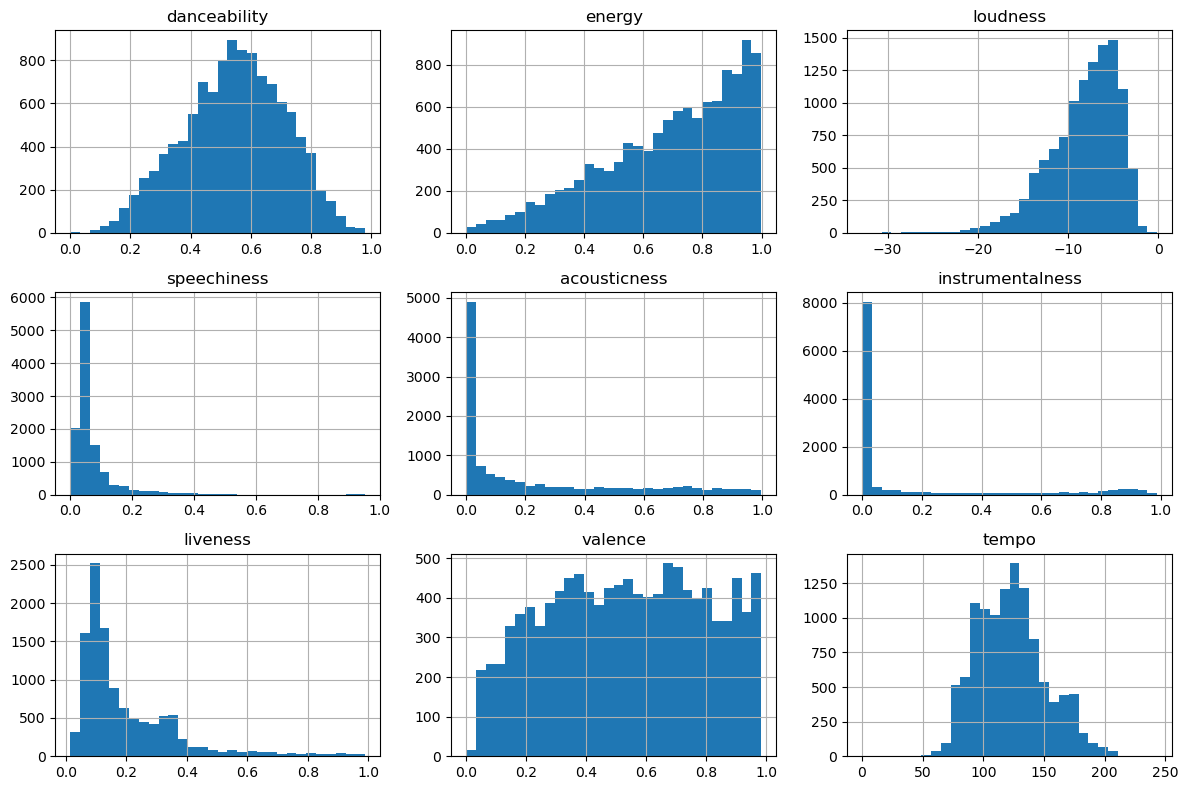

In [ ]:
audio_features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

clean_merged[audio_features].hist(
    bins=30,
    figsize=(12,8)
)

plt.tight_layout()
plt.show()

#### Feature correlation

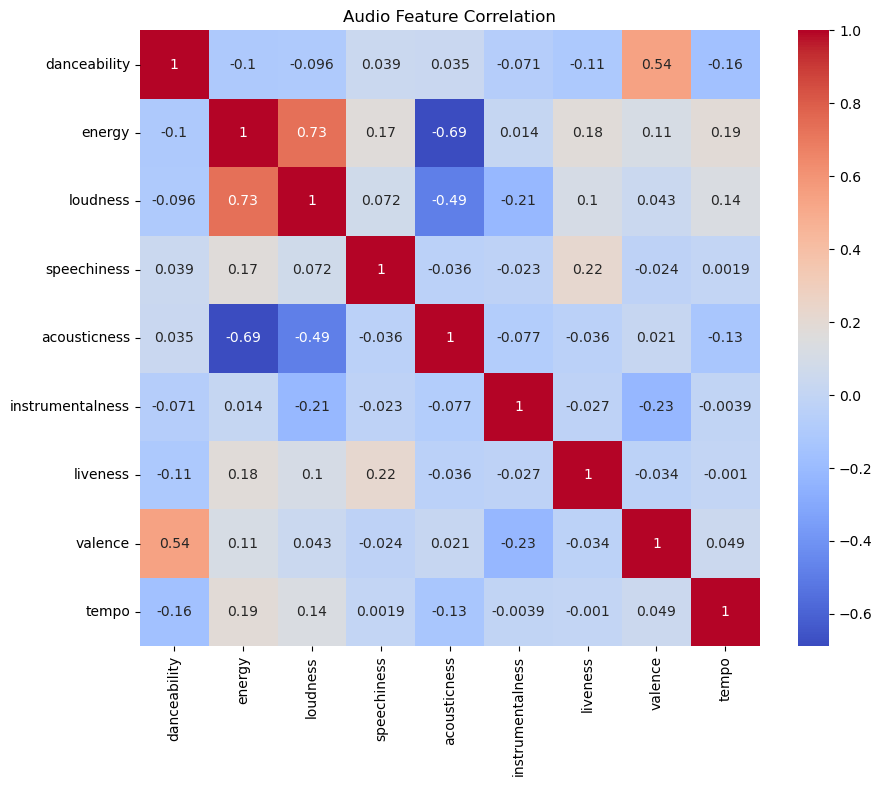

In [18]:
plt.figure(figsize=(10,8))

sns.heatmap(
    clean_merged[audio_features].corr(),
    cmap="coolwarm",
    annot=True
)

plt.title("Audio Feature Correlation")
plt.show()

#### Genre distribution

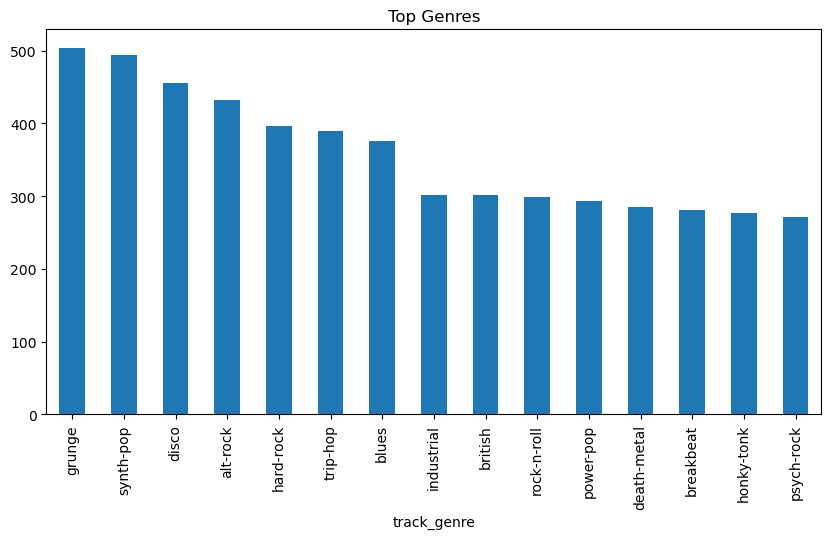

In [20]:
clean_merged["track_genre"].value_counts().head(15).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top Genres")
plt.show()

#### Popularity distribution

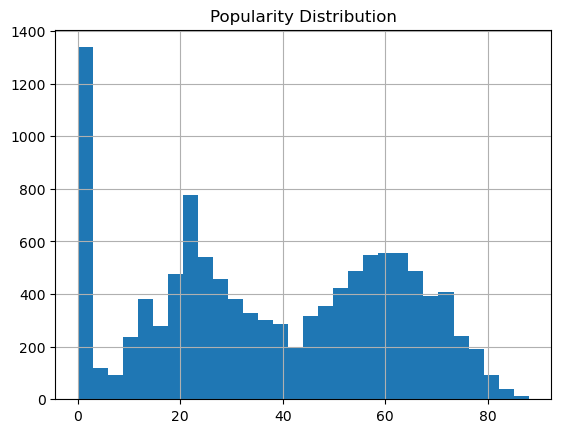

In [21]:
clean_merged["popularity"].hist(bins=30)
plt.title("Popularity Distribution")
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

X = clean_merged[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

clean_merged["pca1"] = X_pca[:,0]
clean_merged["pca2"] = X_pca[:,1]
clean_merged["pca3"] = X_pca[:,2]

import plotly.express as px

fig = px.scatter_3d(
    clean_merged,
    x="pca1",
    y="pca2",
    z="pca3",
    color="track_genre",
    opacity=0.6
)
fig.update_traces(marker=dict(size=4))
fig.update_layout(
    width=1000,
    height=800
)
fig.show()

# Content-based recommendation

In [35]:
nn_model = NearestNeighbors(
    metric="cosine",
    algorithm="brute",
    n_neighbors=11
)

nn_model.fit(X_scaled)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",11
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'brute'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'cosine'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


### Song index mapping

In [36]:
songid_to_idx = {
    sid: i for i, sid in enumerate(clean_merged["song_id"])
}

idx_to_song = {
    i: sid for i, sid in enumerate(clean_merged["song_id"])
}

### Recommendation function

In [41]:
def recommend_similar_songs(song_id, N=10):

    idx = songid_to_idx[song_id]

    distances, indices = nn_model.kneighbors(
        X_scaled[idx].reshape(1, -1),
        n_neighbors=N+1
    )

    rec_idxs = indices[0][1:]
    rec_dist = distances[0][1:]

    rec_df = clean_merged.iloc[rec_idxs][
        ["song_id","title_x","artist_name_x","track_genre"]
    ].copy()

    rec_df["similarity"] = 1 - rec_dist

    return rec_df.sort_values("similarity", ascending=False)

### Example usage

In [42]:
song_id = clean_merged.iloc[3]["song_id"]

recommend_similar_songs(song_id)

,song_id,title_x,artist_name_x,track_genre,similarity
12348,SOSEGYU12AB0180DBB,Call Me [Warner Germany Acoustic Session] (Aco...,Shinedown,grunge,1.000000
7963,SOGMXCA12A8C130568,Babe,Styx,hard-rock,0.952224
15057,SOGHEOF12A8C1420C0,All By Myself,Il Divo,opera,0.948586
2356,SOJILSK12A8C13F427,All By Myself (Solo Otra Vez),Il Divo,opera,0.948586
9393,SOAOXTT12AB0182E23,Harder Than You Know,Escape The Fate,metalcore,0.946800
16010,SOFKNZZ12AB0184F5F,This I Love,Guns N' Roses,hard-rock,0.946158
5033,SOLCMOQ12D0219A9B2,Bedshaped,Keane,piano,0.944444
5576,SOKMZQL12A58A76B19,Believe (Album Version),Josh Groban,opera,0.941127
16423,SOYFTDG12A8AE467AA,Melt My Heart To Stone (album),Adele,british,0.928945
5890,SOPIQOW12AB017E920,Melt My Heart To Stone (Live At Hotel Cafe),Adele,british,0.928945


# Evaluation

In [44]:
song = clean_merged.iloc[100]

print("Input Song:")
print(song["title_x"], "-", song["artist_name_x"], "-", song["track_genre"])

print("\nRecommended Songs:")

recommend_similar_songs(song["song_id"], N=5)

Input Song:
I Ran (So Far Away) (Die Krupps Remix) - A Flock Of Seagulls - synth-pop

Recommended Songs:


,song_id,title_x,artist_name_x,track_genre,similarity
19303,SODHBVU12AB0182D78,I Ran,A Flock Of Seagulls,synth-pop,1.0
18417,SOTTKFZ12A6D4FA03B,I Ran (L Remix),A Flock Of Seagulls,synth-pop,1.0
16241,SOZLOCQ12AB018775F,I Ran,A Flock Of Seagulls,synth-pop,1.0
3693,SOKRPAO12A8C14530C,I Ran (So Far Away),A Flock Of Seagulls,synth-pop,1.0
8227,SOFCHIM12A8C138635,I Ran,A Flock Of Seagulls,synth-pop,1.0


## Save model

In [49]:
import joblib

joblib.dump(nn_model, "../models/content_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")
clean_merged.to_csv("../models/song_features.csv", index=False)